# Module 01: Tensors

## Introduction

The foundation of everything in deep learning. Before we can build a
language model, we need to understand tensors - the data structure that
holds all our numbers.

A **tensor** is a multi-dimensional array of numbers. If you’ve used
NumPy arrays, you already know what tensors are - PyTorch tensors are
nearly identical, but with GPU acceleration and automatic
differentiation built in.

Why do we need them for LLMs?

-   **Text becomes numbers**: Every word/token gets converted to a list
    of numbers (a vector)
-   **Batching**: We process multiple sequences at once for efficiency
-   **Matrix operations**: Attention, embeddings, and neural network
    layers are all matrix multiplications

### What Makes PyTorch Tensors Special

Unlike NumPy arrays, PyTorch tensors provide:

1.  **GPU acceleration**: Seamlessly move computations to GPU for
    10-100x speedup
2.  **Automatic differentiation**: Track operations to compute gradients
    (covered in Module 02)
3.  **Optimized kernels**: BLAS/cuBLAS backends for highly efficient
    linear algebra

## Tensor Dimensions

Think of tensors by their dimensions:

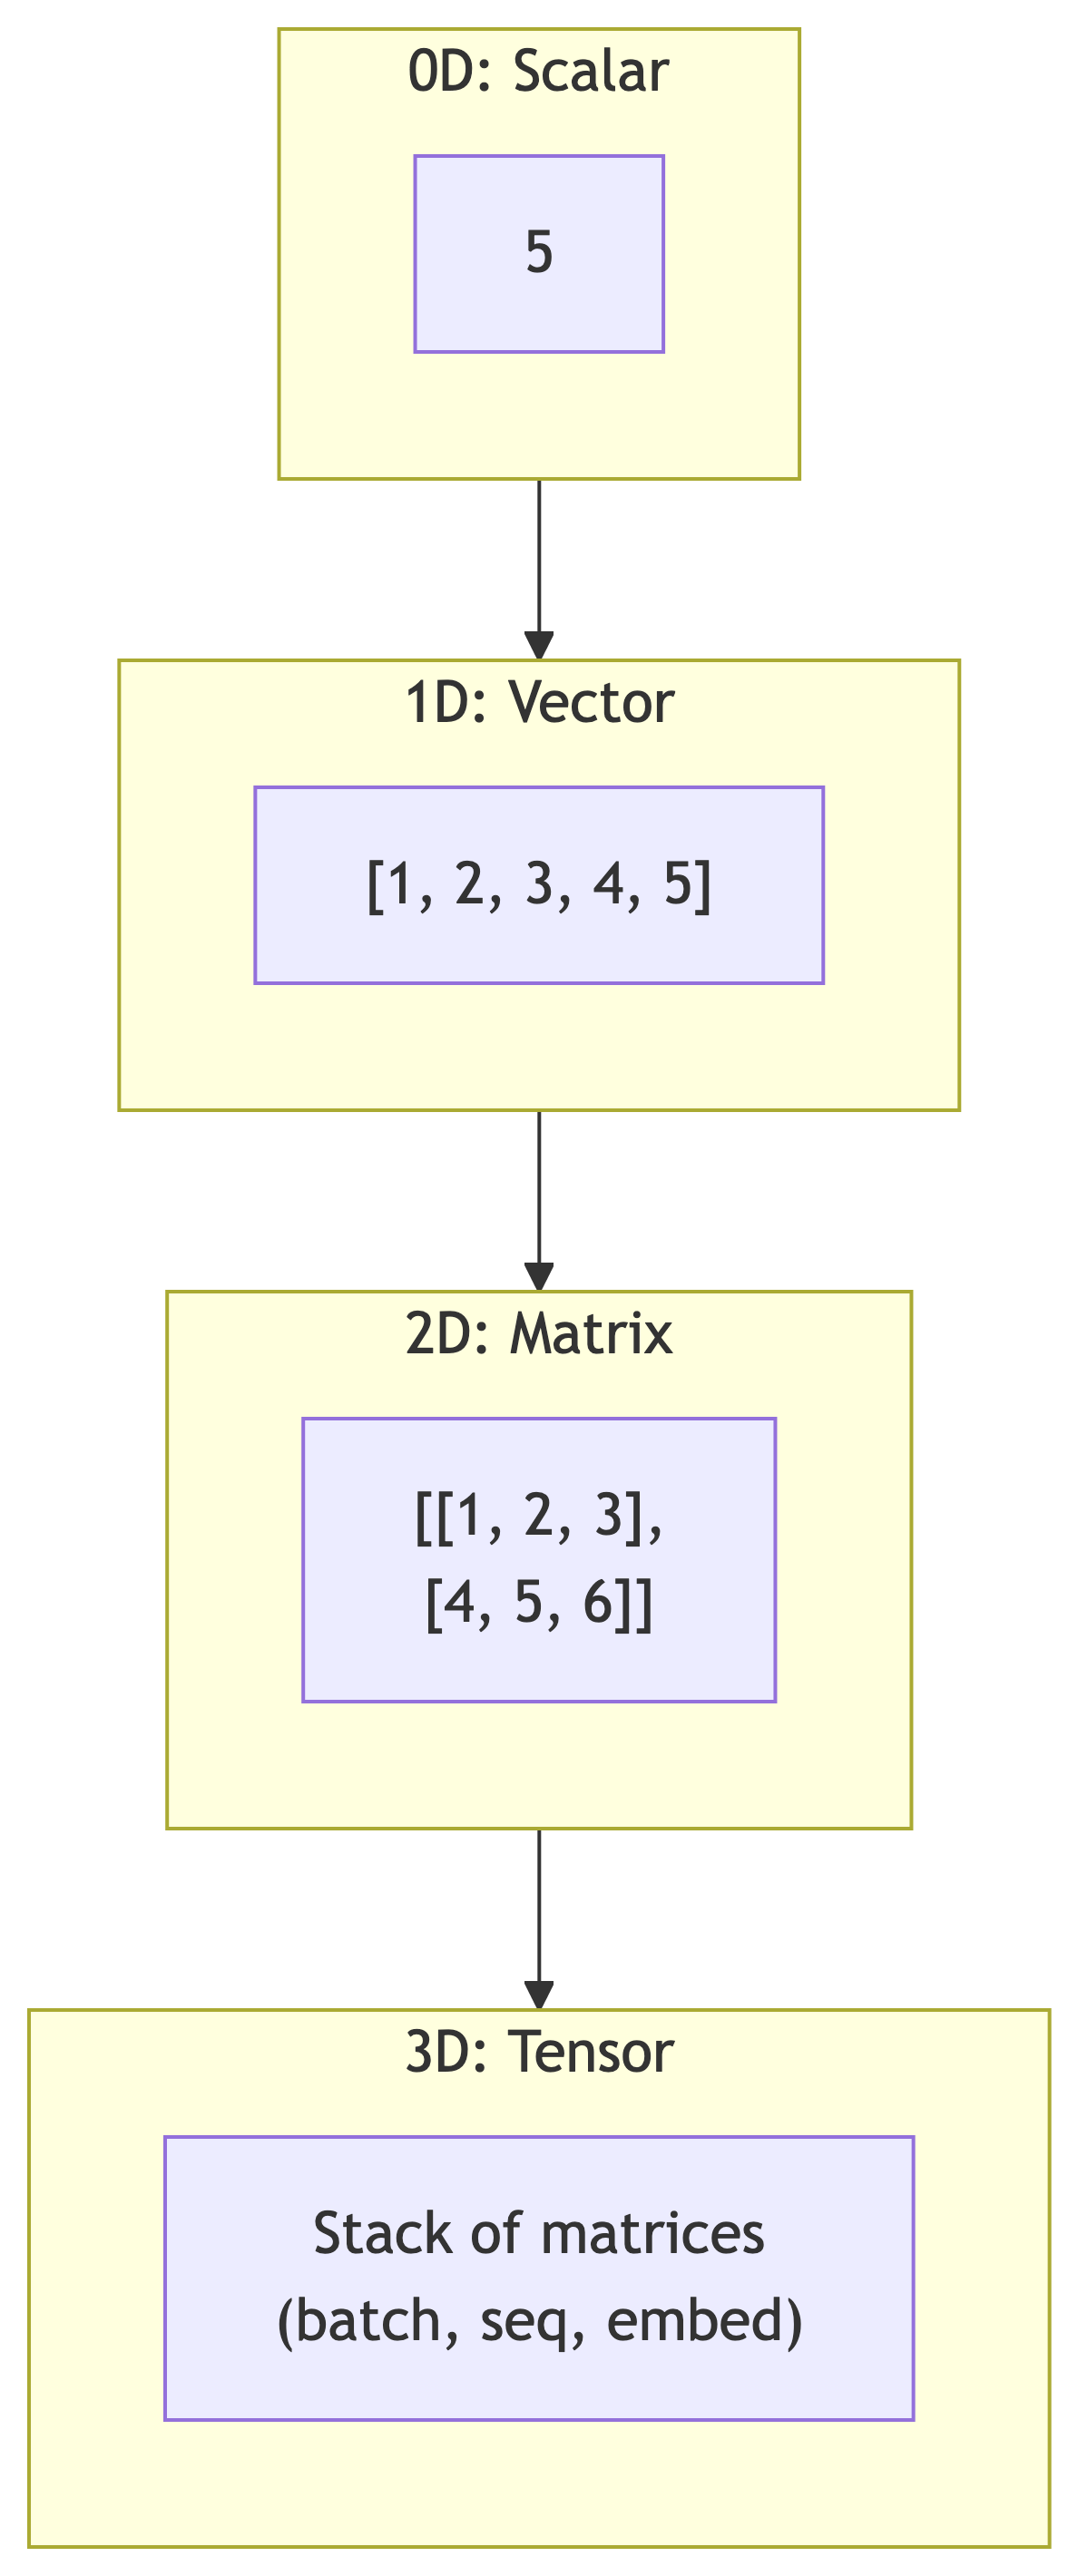

The shape of a tensor tells you what it represents. In an LLM:

-   `(vocab_size,)` - A 1D tensor: scores for each word in vocabulary
-   `(seq_len, embed_dim)` - A 2D tensor: one embedding vector per token
-   `(batch, seq_len, embed_dim)` - A 3D tensor: multiple sequences at
    once

## LLM Tensor Shapes

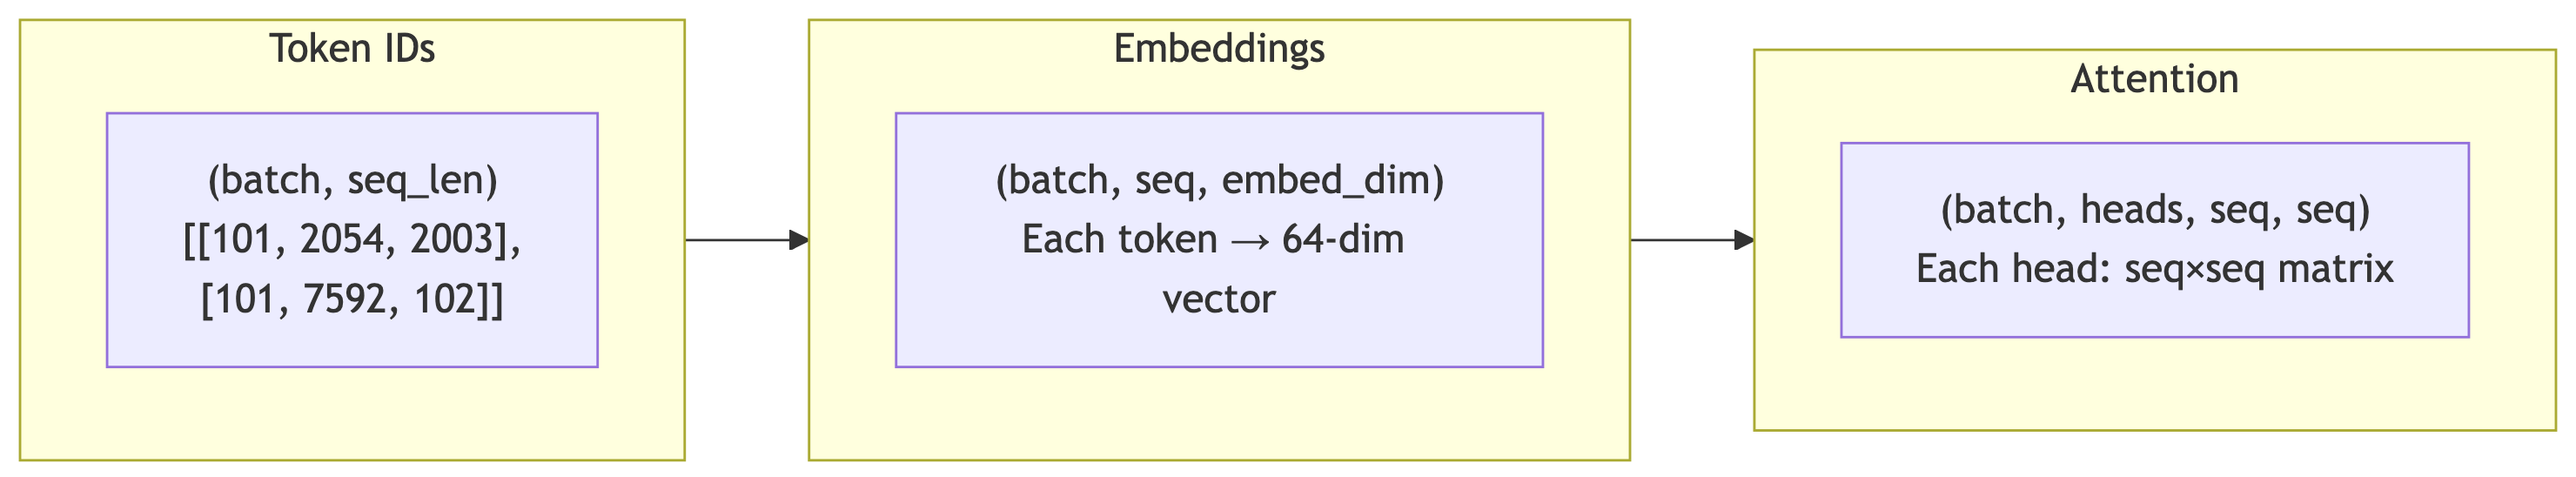

## The Math

### Element-wise Operations

Apply the same operation to every element:

``` python
[1, 2, 3] + [4, 5, 6] = [5, 7, 9]
[1, 2, 3] * 2 = [2, 4, 6]
```

### Matrix Multiplication

The core operation of neural networks. For matrices A (m×n) and B (n×p):

    C = A @ B  →  C is (m×p)
    C[i,j] = sum(A[i,k] * B[k,j] for k in range(n))

### Broadcasting

When shapes don’t match, PyTorch automatically expands smaller tensors:

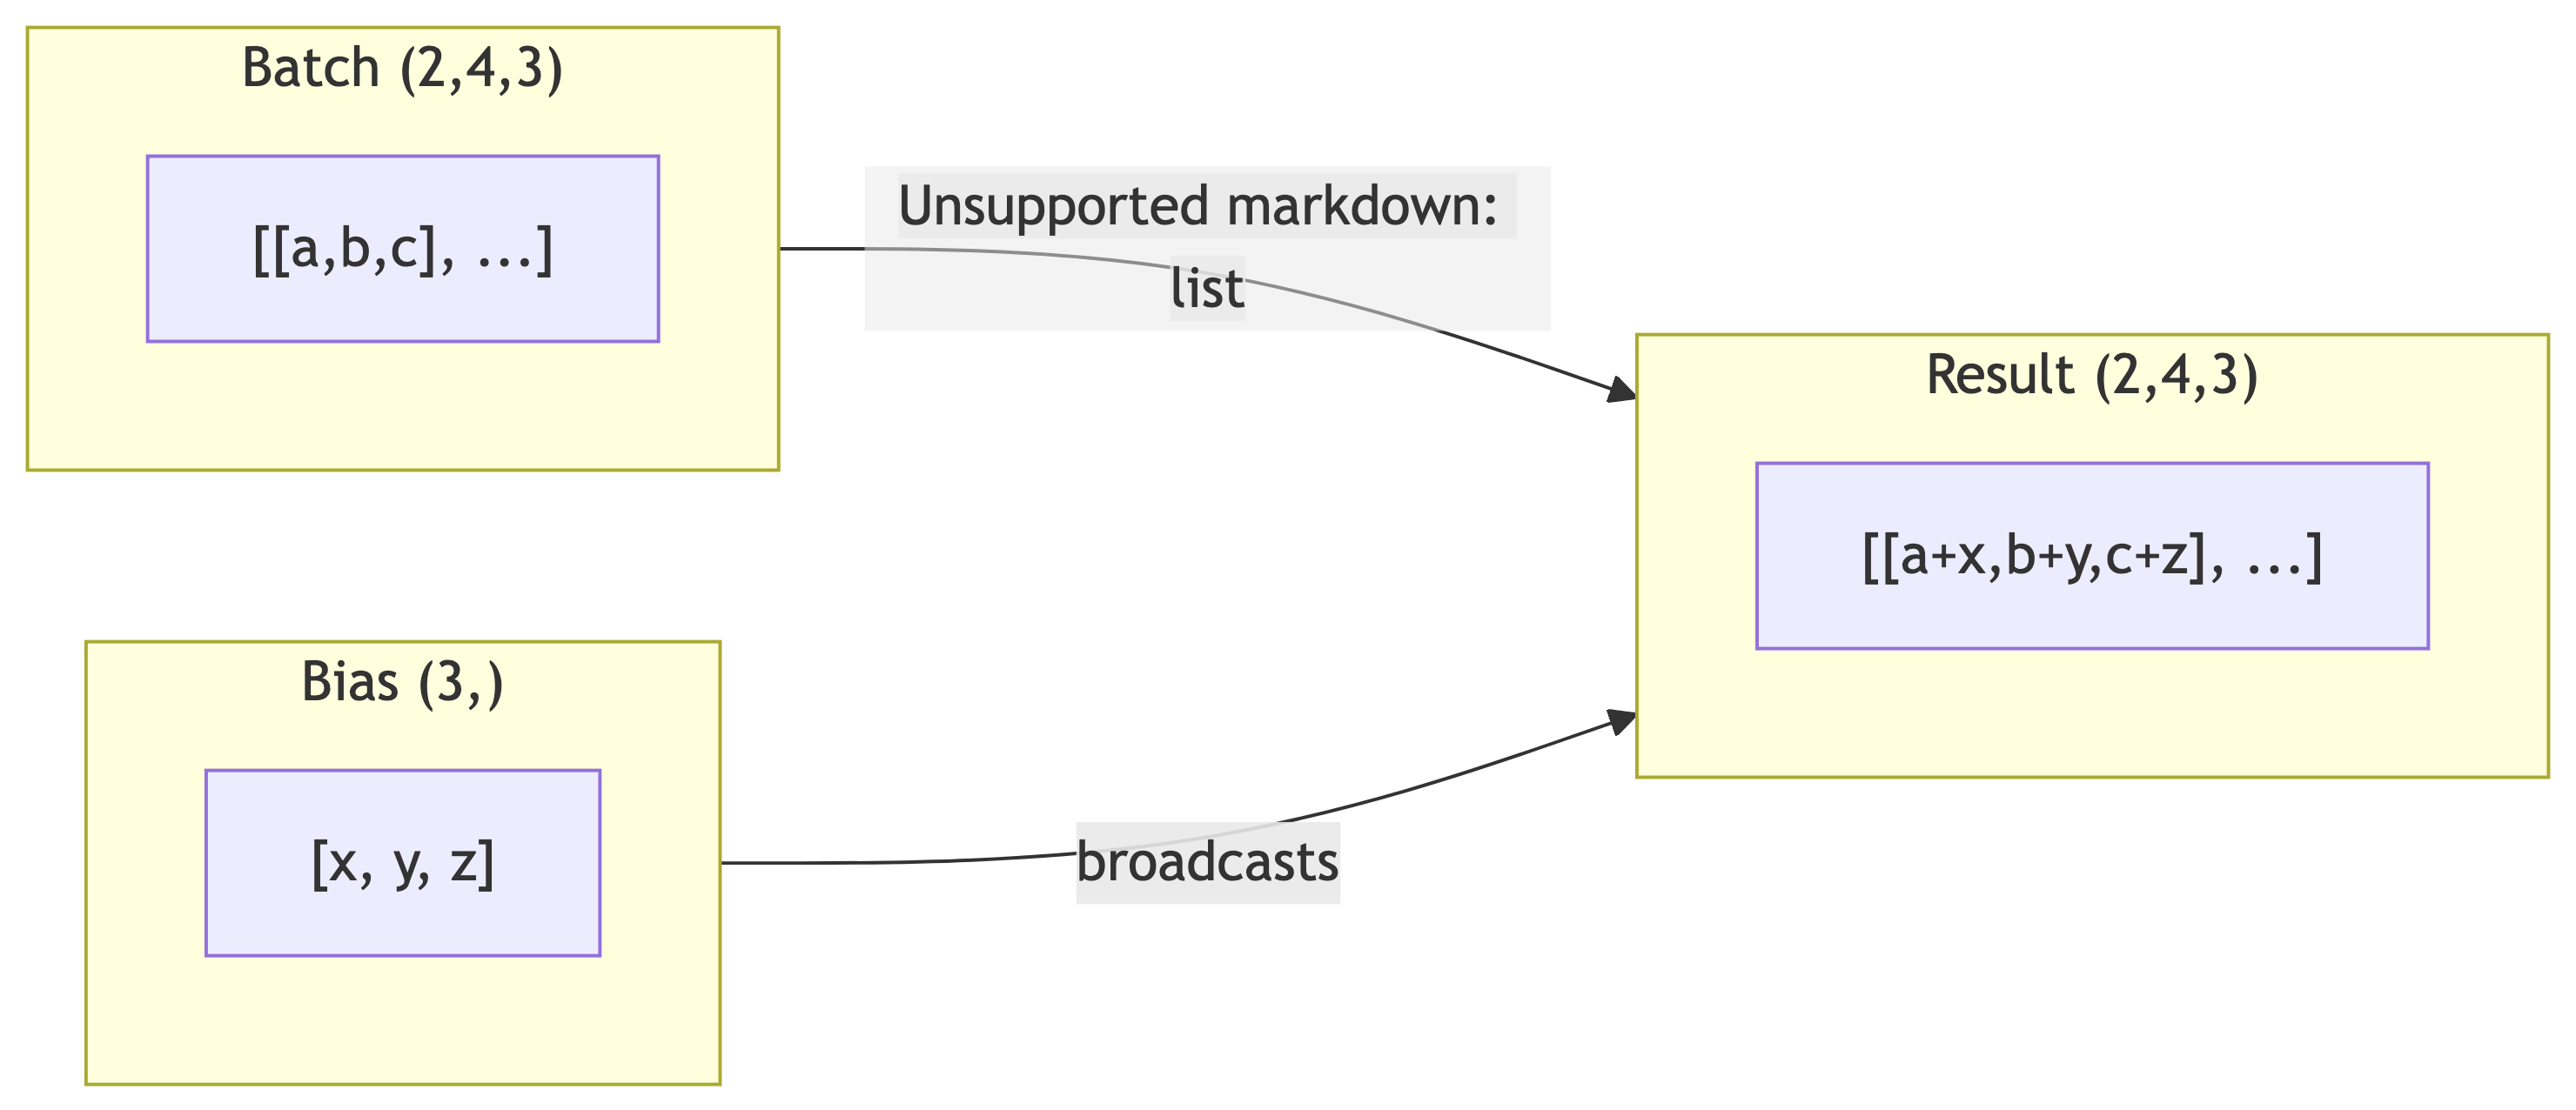

Broadcasting rules:

1.  Align shapes from the right
2.  Dimensions must match OR be 1 (or missing)
3.  Size-1 dimensions get repeated to match

## Code Walkthrough

Let’s explore tensors interactively:

In [1]:
import torch

print(f"PyTorch version: {torch.__version__}")
device = "mps" if torch.backends.mps.is_available() else "cpu"
print(f"Device: {device}")

PyTorch version: 2.9.1
Device: mps

### Creating Tensors

In [2]:
# From a list
x = torch.tensor([[1.0, 2.0, 3.0], [4.0, 5.0, 6.0]])
print(f"Shape: {x.shape}")
print(f"Dtype: {x.dtype}")
print(f"Device: {x.device}")
print(x)

Shape: torch.Size([2, 3])
Dtype: torch.float32
Device: cpu
tensor([[1., 2., 3.],
        [4., 5., 6.]])

In [3]:
# Random tensors (common for initialization)
random_tensor = torch.randn(2, 3, 4)  # Normal distribution (mean=0, std=1)
print(f"Random tensor shape: {random_tensor.shape}")
print(f"Mean: {random_tensor.mean():.4f}, Std: {random_tensor.std():.4f}")

Random tensor shape: torch.Size([2, 3, 4])
Mean: -0.0431, Std: 0.9452

### Data Types (dtypes)

Choosing the right dtype affects memory usage and numerical precision:

In [4]:
# Default is float32 (32 bits = 4 bytes per number)
t32 = torch.randn(1000, 1000)
print(f"float32: {t32.element_size()} bytes per element, total: {t32.numel() * t32.element_size() / 1e6:.1f} MB")

# float16 uses half the memory but lower precision
t16 = torch.randn(1000, 1000, dtype=torch.float16)
print(f"float16: {t16.element_size()} bytes per element, total: {t16.numel() * t16.element_size() / 1e6:.1f} MB")

# bfloat16 is popular for training (better range than float16)
tbf16 = torch.randn(1000, 1000, dtype=torch.bfloat16)
print(f"bfloat16: {tbf16.element_size()} bytes per element")

float32: 4 bytes per element, total: 4.0 MB
float16: 2 bytes per element, total: 2.0 MB
bfloat16: 2 bytes per element

**When to use each:**

-   **float32**: Default, good for learning and debugging
-   **float16**: Inference on GPUs with Tensor Cores, half memory
-   **bfloat16**: Training large models, better numerical stability than
    float16

### Reshaping

Reshaping is critical for multi-head attention, where we split the
embedding dimension across multiple heads:

In [5]:
# Reshape for multi-head attention
batch, seq, embed = 4, 32, 64
num_heads = 8
head_dim = embed // num_heads

x = torch.randn(batch, seq, embed)
print(f"Original: {x.shape}")

# Split into heads
x_heads = x.view(batch, seq, num_heads, head_dim)
print(f"After view: {x_heads.shape}")

# Transpose for attention computation
x_heads = x_heads.transpose(1, 2)  # (batch, heads, seq, head_dim)
print(f"After transpose: {x_heads.shape}")

Original: torch.Size([4, 32, 64])
After view: torch.Size([4, 32, 8, 8])
After transpose: torch.Size([4, 8, 32, 8])

### Memory Layout: view vs reshape vs contiguous

Understanding memory layout helps avoid subtle bugs:

In [6]:
# view() requires contiguous memory - it's a zero-copy operation
x = torch.randn(3, 4)
print(f"Original is contiguous: {x.is_contiguous()}")

# Transpose creates a non-contiguous view (same memory, different strides)
x_t = x.transpose(0, 1)
print(f"Transposed is contiguous: {x_t.is_contiguous()}")

# view() fails on non-contiguous tensors
try:
    x_t.view(12)  # This will fail
except RuntimeError as e:
    print(f"Error: {e}")

# contiguous() makes a copy with proper memory layout
x_t_contig = x_t.contiguous()
print(f"After contiguous(): {x_t_contig.is_contiguous()}")
x_t_contig.view(12)  # Now it works
print("view() works after contiguous()")

# reshape() handles this automatically (but may copy)
reshaped = x_t.reshape(12)  # Always works
print(f"reshape() auto-handles non-contiguous: {reshaped.shape}")

Original is contiguous: True
Transposed is contiguous: False
Error: view size is not compatible with input tensor's size and stride (at least one dimension spans across two contiguous subspaces). Use .reshape(...) instead.
After contiguous(): True
view() works after contiguous()
reshape() auto-handles non-contiguous: torch.Size([12])

**Rule of thumb**: Use `reshape()` unless you specifically need
zero-copy behavior.

### Matrix Multiplication

Matrix multiplication is the workhorse of neural networks. The `@`
operator (or `torch.matmul`) handles batched operations automatically:

In [7]:
# Simulating Q @ K^T in attention
Q = torch.randn(2, 8, 32, 8)  # (batch, heads, seq, head_dim)
K = torch.randn(2, 8, 32, 8)

# Attention scores
scores = Q @ K.transpose(-2, -1)  # (batch, heads, seq, seq)
print(f"Q shape: {Q.shape}")
print(f"K^T shape: {K.transpose(-2, -1).shape}")
print(f"Scores shape: {scores.shape}")

Q shape: torch.Size([2, 8, 32, 8])
K^T shape: torch.Size([2, 8, 8, 32])
Scores shape: torch.Size([2, 8, 32, 32])

**Key insight**: The last two dimensions follow standard matrix
multiplication rules `(m, k) @ (k, n) -> (m, n)`, while leading
dimensions are broadcasted/batched.

### Softmax: Converting Scores to Probabilities

Softmax takes a vector of arbitrary real numbers (**logits**) and
converts them into a **probability distribution** — values between 0 and
1 that sum to 1.

$$\text{softmax}(z_i) = \frac{e^{z_i}}{\sum_{j=1}^{n} e^{z_j}}$$

The exponential function amplifies differences — larger values get
disproportionately larger weights:

In [8]:
import torch

logits = torch.tensor([2.0, 1.0, 0.1])
probs = torch.softmax(logits, dim=-1)

print(f"Logits: {logits.tolist()}")
print(f"Probs:  {[f'{p:.3f}' for p in probs.tolist()]}")
print(f"Sum:    {probs.sum():.3f}")

Logits: [2.0, 1.0, 0.10000000149011612]
Probs:  ['0.659', '0.242', '0.099']
Sum:    1.000

The highest logit (2.0) gets ~65% of the probability mass. This is how
attention weights and next-token predictions work.

**The `dim` parameter matters** — it specifies which dimension sums to
1:

In [9]:
# Batch of scores: (batch=2, seq=3)
scores = torch.randn(2, 3)
weights = torch.softmax(scores, dim=-1)  # Each row sums to 1

print(f"Row sums: {weights.sum(dim=-1)}")  # [1.0, 1.0]

Row sums: tensor([1.0000, 1.0000])

**Tip**: Always use `torch.softmax()` — it handles numerical stability
automatically. For details on temperature scaling, see [Module 08:
Generation](../m08_generation/lesson.qmd). For softmax in attention, see
[Module 05: Attention](../m05_attention/lesson.qmd).

### Common Operations in LLMs

These operations appear everywhere in transformer models:

In [10]:
# Layer Normalization (normalizes features, not batch)
x = torch.randn(4, 32, 64)  # (batch, seq, embed)
mean = x.mean(dim=-1, keepdim=True)
std = x.std(dim=-1, keepdim=True)
x_norm = (x - mean) / (std + 1e-5)
print(f"LayerNorm output shape: {x_norm.shape}")
print(f"Mean per token: {x_norm.mean(dim=-1)[0, :3]}")  # Should be ~0

# Linear projection (the most common operation)
W = torch.randn(64, 256)  # (in_features, out_features)
b = torch.randn(256)       # (out_features,)
x = torch.randn(4, 32, 64) # (batch, seq, in_features)
out = x @ W + b            # Broadcasting adds bias
print(f"Linear output shape: {out.shape}")

LayerNorm output shape: torch.Size([4, 32, 64])
Mean per token: tensor([-1.8626e-08,  0.0000e+00, -2.6077e-08])
Linear output shape: torch.Size([4, 32, 256])

### Broadcasting in Action

In [11]:
# Adding bias to all tokens in a batch
embeddings = torch.randn(4, 32, 64)  # (batch, seq, embed)
bias = torch.randn(64)               # (embed,)

result = embeddings + bias  # Broadcasts!
print(f"Embeddings: {embeddings.shape}")
print(f"Bias: {bias.shape}")
print(f"Result: {result.shape}")

Embeddings: torch.Size([4, 32, 64])
Bias: torch.Size([64])
Result: torch.Size([4, 32, 64])

### Device Management (CPU vs GPU)

Moving tensors between devices is essential for GPU acceleration:

In [12]:
# Check available devices
print(f"MPS available: {torch.backends.mps.is_available()}")
print(f"CUDA available: {torch.cuda.is_available()}")

# Create tensor on specific device
device = "mps" if torch.backends.mps.is_available() else "cpu"
x = torch.randn(1000, 1000, device=device)
print(f"Tensor device: {x.device}")

# Move existing tensor to device
y = torch.randn(1000, 1000)  # Created on CPU by default
y = y.to(device)             # Move to GPU
print(f"After .to(): {y.device}")

MPS available: True
CUDA available: False
Tensor device: mps:0
After .to(): mps:0

**Common pitfall**: Operations require tensors on the same device:

In [13]:
# This would fail if devices differ:
# z = x_cpu + x_gpu  # RuntimeError!

# Always ensure tensors are on the same device
a = torch.randn(100, device=device)
b = torch.randn(100, device=device)
c = a + b  # Works!
print(f"Both on {device}: operation succeeded")

Both on mps: operation succeeded

## Exercises

### Exercise 1: Create an Embedding Lookup

In [14]:
# Create a vocabulary embedding table
vocab_size = 100
embed_dim = 32

embedding_table = torch.randn(vocab_size, embed_dim)
print(f"Embedding table: {embedding_table.shape}")

# Look up embeddings for token IDs
token_ids = torch.tensor([5, 23, 7, 42])
embeddings = embedding_table[token_ids]
print(f"Token IDs: {token_ids}")
print(f"Embeddings shape: {embeddings.shape}")

Embedding table: torch.Size([100, 32])
Token IDs: tensor([ 5, 23,  7, 42])
Embeddings shape: torch.Size([4, 32])

### Exercise 2: Simulate Simple Attention

Attention scores shape: torch.Size([6, 6])

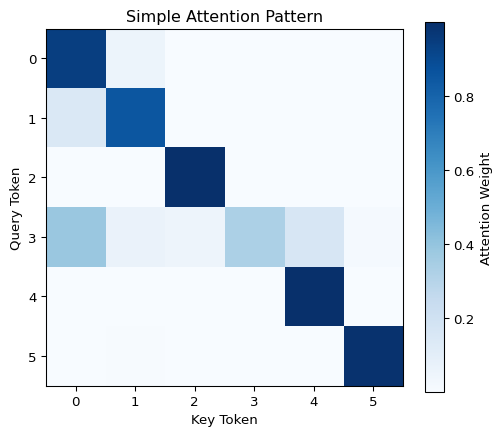

In [15]:
import matplotlib.pyplot as plt

seq_len = 6
embed_dim = 8

# Token embeddings
tokens = torch.randn(seq_len, embed_dim)

# Compute attention scores (dot product similarity)
scores = tokens @ tokens.T
print(f"Attention scores shape: {scores.shape}")

# Apply softmax to get weights
attention_weights = torch.softmax(scores, dim=-1)

# Visualize
plt.figure(figsize=(6, 5))
plt.imshow(attention_weights.detach().numpy(), cmap='Blues')
plt.colorbar(label='Attention Weight')
plt.title('Simple Attention Pattern')
plt.xlabel('Key Token')
plt.ylabel('Query Token')
plt.show()

### Exercise 3: Apply Attention

In [16]:
# Weighted combination of values
output = attention_weights @ tokens
print(f"Input: {tokens.shape}")
print(f"Weights: {attention_weights.shape}")
print(f"Output: {output.shape}")
print("\nEach output token is a weighted average of ALL input tokens!")

Input: torch.Size([6, 8])
Weights: torch.Size([6, 6])
Output: torch.Size([6, 8])

Each output token is a weighted average of ALL input tokens!

## Common Pitfalls

Before moving on, be aware of these common mistakes:

1.  **Shape mismatches**: Always print shapes when debugging. Most
    errors come from unexpected dimensions.
2.  **Device mismatches**: Tensors must be on the same device for
    operations. Use `.to(device)` consistently.
3.  **In-place operations**: Methods ending in `_` (like `add_()`)
    modify tensors in-place, which can break gradient computation.
4.  **Forgetting contiguous()**: After transpose/permute, call
    `.contiguous()` before `.view()`.
5.  **dtype mismatches**: Operations between float32 and float16 may
    silently upcast or fail.

## Summary

Key takeaways:

1.  **Tensors are multi-dimensional arrays** - their shape tells you
    what they represent
2.  **Broadcasting** automatically expands smaller tensors to match
    larger ones
3.  **Matrix multiplication** is the core operation - inner dimensions
    must match
4.  **Reshaping** reorganizes dimensions without changing total elements
5.  **Memory layout matters** - understand contiguous vs strided for
    efficient operations
6.  **Device placement** - use GPU (MPS/CUDA) for 10-100x speedup on
    large tensors
7.  **Data types** - float32 for learning, float16/bfloat16 for
    production

## What’s Next

In [Module 02: Autograd](../m02_autograd/lesson.qmd), we’ll see how
PyTorch automatically computes gradients through all these operations -
the magic that makes neural networks trainable.